## ARIMA

The **full step-by-step Airline example** (load → stationarity → identification → seasonal ARIMA → forecast) is in the **last section** of this notebook.


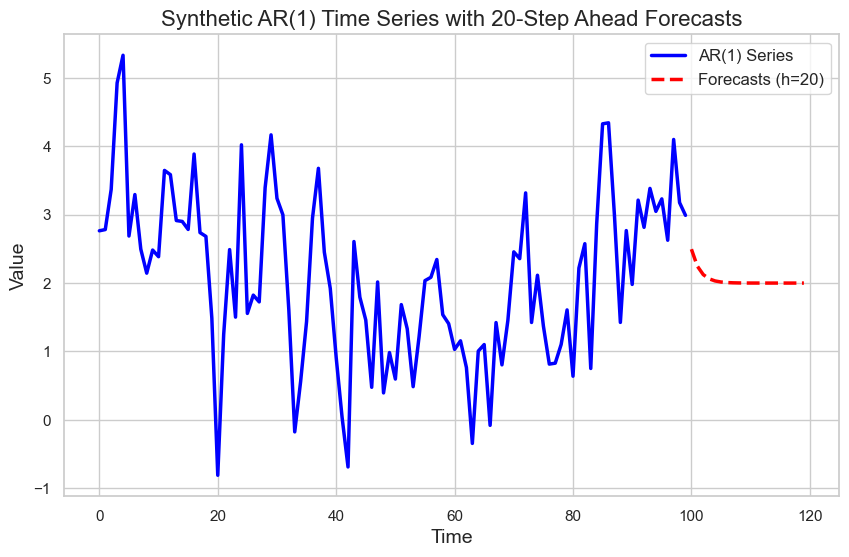

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c = 1
phi = 0.5
sigma = 1
n_steps = 100
forecast_steps = 20

np.random.seed(0)
errors = np.random.normal(0, sigma, n_steps)
y = np.zeros(n_steps)
y[0] = c + errors[0]
for t in range(1, n_steps):
    y[t] = c + phi * y[t-1] + errors[t]


forecast = np.zeros(n_steps + forecast_steps)
forecast[:n_steps] = y
for t in range(n_steps, n_steps + forecast_steps):
    forecast[t] = c + phi * forecast[t-1]

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))


plt.plot(y, label='AR(1) Series', linewidth=2.5, color='blue')


plt.plot(range(n_steps, n_steps + forecast_steps), forecast[n_steps:], linestyle='--', label=f'Forecasts (h={forecast_steps})', linewidth=2.5, color='red')


plt.title('Synthetic AR(1) Time Series with 20-Step Ahead Forecasts', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Value', fontsize=14)

plt.legend(fontsize=12)


plt.show()

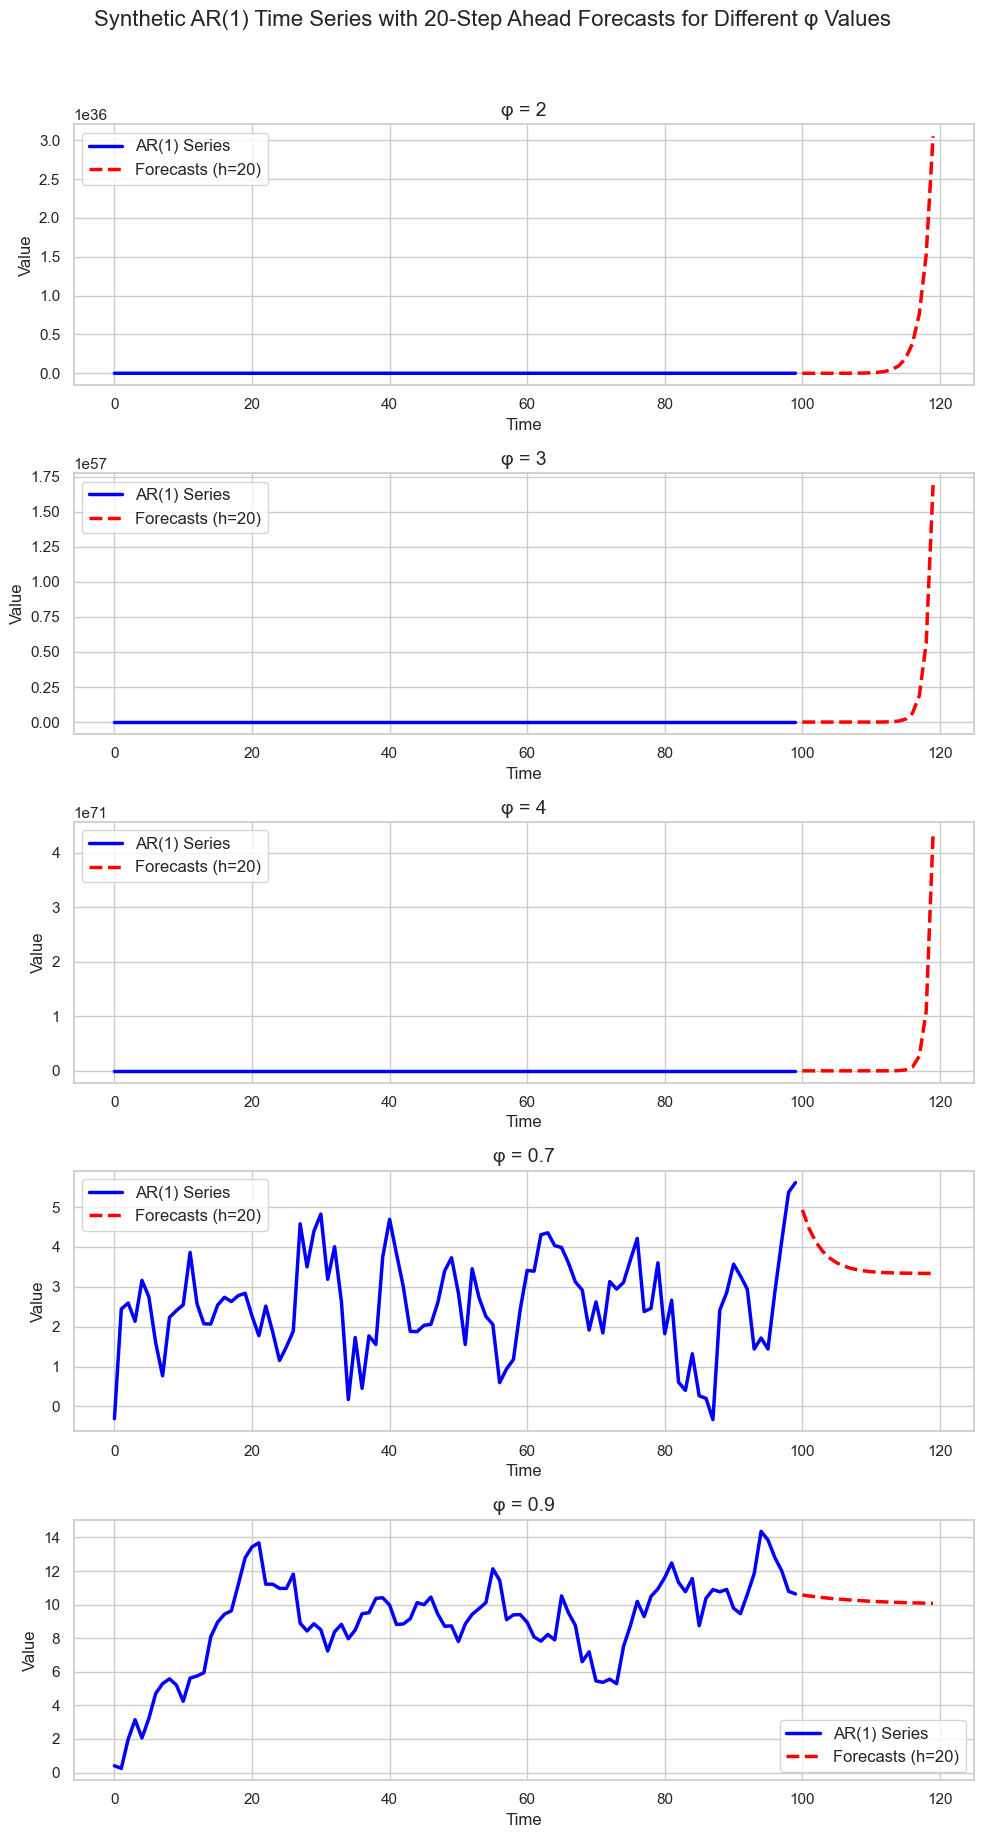

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


c = 1
phis = [2, 3, 4, 0.7, 0.9, ]
sigma = 1
n_steps = 100
forecast_steps = 20

sns.set(style="whitegrid")

fig, axes = plt.subplots(5, 1, figsize=(10, 18))
fig.suptitle('Synthetic AR(1) Time Series with 20-Step Ahead Forecasts for Different φ Values', fontsize=16, y=1.02)

np.random.seed(0)
for i, phi in enumerate(phis):
    errors = np.random.normal(0, sigma, n_steps)
    y = np.zeros(n_steps)
    y[0] = c + errors[0]
    for t in range(1, n_steps):
        y[t] = c + phi * y[t-1] + errors[t]


    forecast = np.zeros(n_steps + forecast_steps)
    forecast[:n_steps] = y
    for t in range(n_steps, n_steps + forecast_steps):
        forecast[t] = c + phi * forecast[t-1]


    axes[i].plot(y, label='AR(1) Series', linewidth=2.5, color='blue')
    axes[i].plot(range(n_steps, n_steps + forecast_steps), forecast[n_steps:], linestyle='--', label=f'Forecasts (h={forecast_steps})', linewidth=2.5, color='red')


    axes[i].set_title(f'φ = {phi}', fontsize=14)
    axes[i].set_xlabel('Time', fontsize=12)
    axes[i].set_ylabel('Value', fontsize=12)


    axes[i].legend(fontsize=12)


plt.tight_layout()

plt.show()

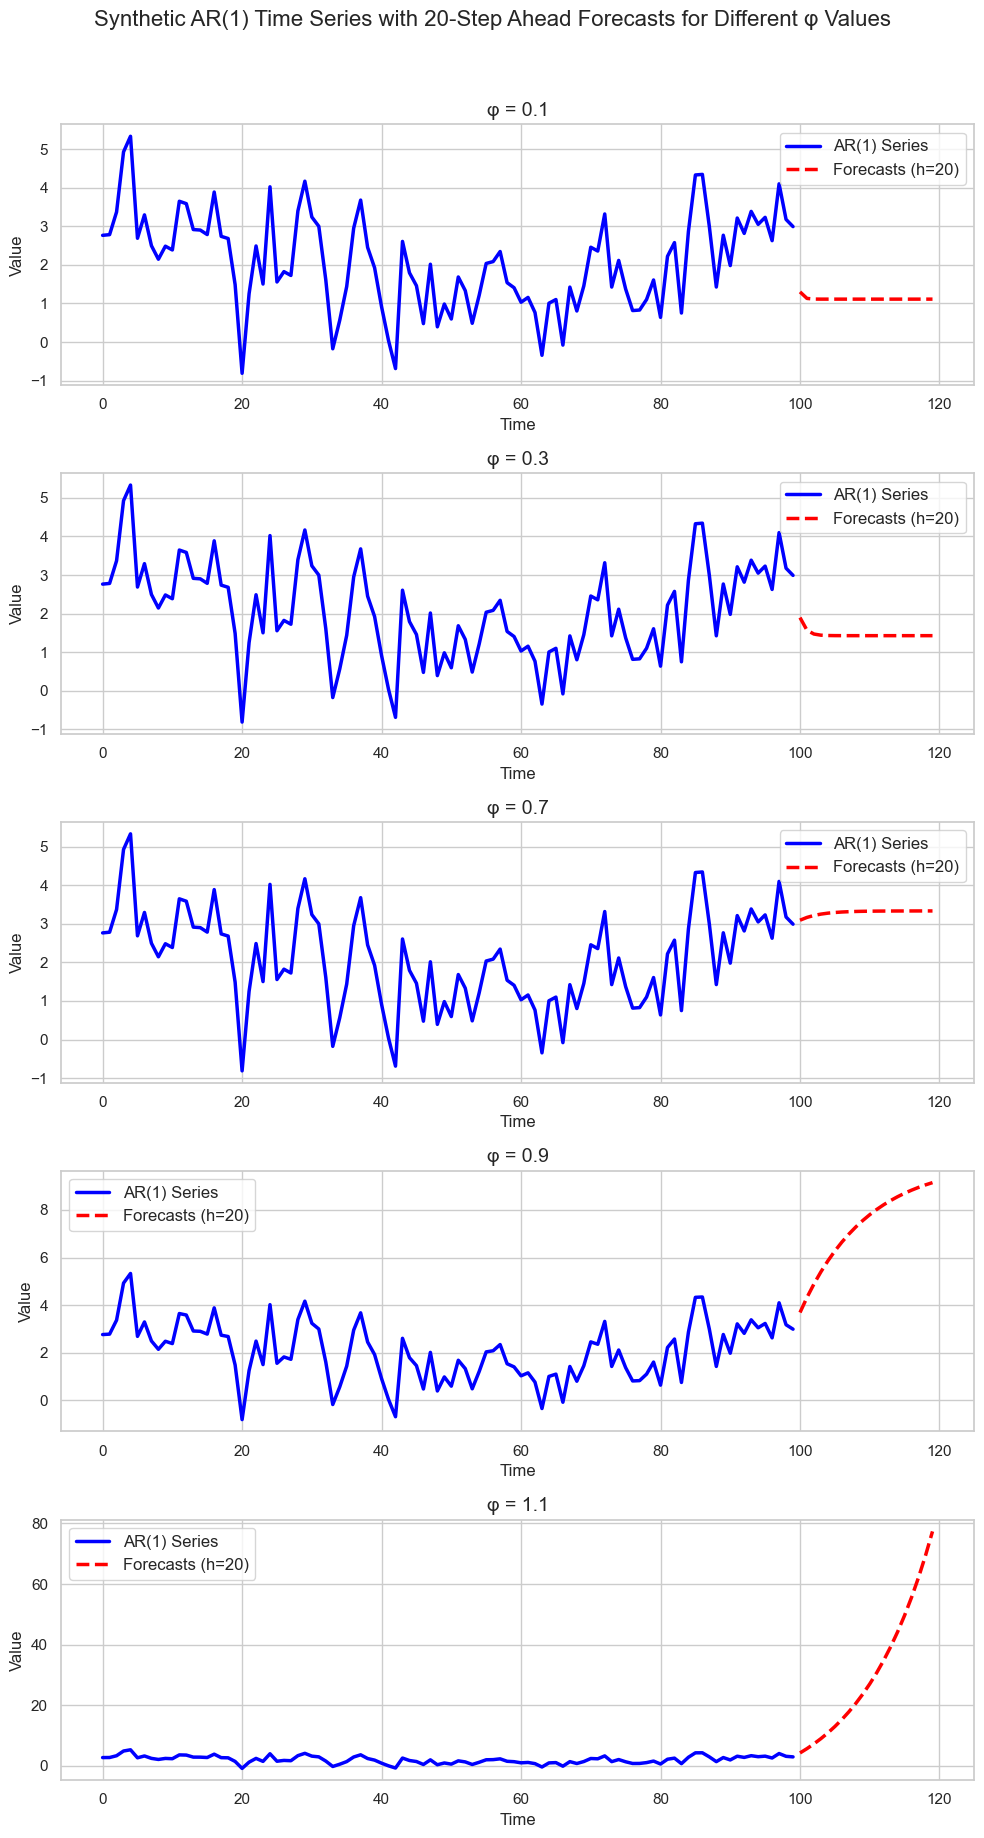

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c = 1
phis = [0.1, 0.3, 0.7, 0.9, 1.1]
sigma = 1
n_steps = 100
forecast_steps = 20

sns.set(style="whitegrid")


fig, axes = plt.subplots(5, 1, figsize=(10, 18))
fig.suptitle('Synthetic AR(1) Time Series with 20-Step Ahead Forecasts for Different φ Values', fontsize=16, y=1.02)


np.random.seed(0)
errors = np.random.normal(0, sigma, n_steps)
y = np.zeros(n_steps)
y[0] = c + errors[0]
for t in range(1, n_steps):
    y[t] = c + 0.5 * y[t-1] + errors[t]


for i, phi in enumerate(phis):

    forecast = np.zeros(n_steps + forecast_steps)
    forecast[:n_steps] = y


    for t in range(n_steps, n_steps + forecast_steps):
        forecast[t] = c + phi * forecast[t-1]


    axes[i].plot(y, label='AR(1) Series', linewidth=2.5, color='blue')
    axes[i].plot(range(n_steps, n_steps + forecast_steps), forecast[n_steps:], linestyle='--', label=f'Forecasts (h={forecast_steps})', linewidth=2.5, color='red')


    axes[i].set_title(f'φ = {phi}', fontsize=14)
    axes[i].set_xlabel('Time', fontsize=12)
    axes[i].set_ylabel('Value', fontsize=12)


    axes[i].legend(fontsize=12)


plt.tight_layout()


plt.show()

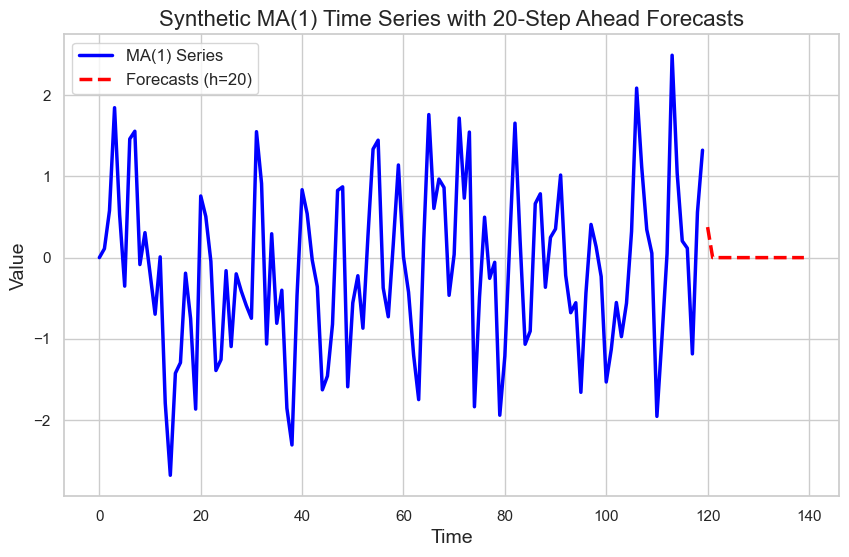

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


mu = 0
theta = 0.5
sigma = 1
n_steps = 120
forecast_steps = 20


np.random.seed(42)
epsilon = np.random.normal(0, sigma, n_steps + forecast_steps)


y = np.zeros(n_steps)
for t in range(1, n_steps):
    y[t] = mu + theta * epsilon[t-1] + epsilon[t]


forecast = np.zeros(n_steps + forecast_steps)
forecast[:n_steps] = y
for t in range(n_steps, n_steps + forecast_steps):
    if t == n_steps:
        forecast[t] = mu + theta * epsilon[t-1]
    else:
        forecast[t] = mu


sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))


plt.plot(y, label='MA(1) Series', linewidth=2.5, color='blue')


plt.plot(range(n_steps, n_steps + forecast_steps), forecast[n_steps:],
         linestyle='--', label=f'Forecasts (h={forecast_steps})', linewidth=2.5, color='red')


plt.title('Synthetic MA(1) Time Series with 20-Step Ahead Forecasts', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Value', fontsize=14)


plt.legend(fontsize=12)


plt.show()

## ARIMA Tutorials V2

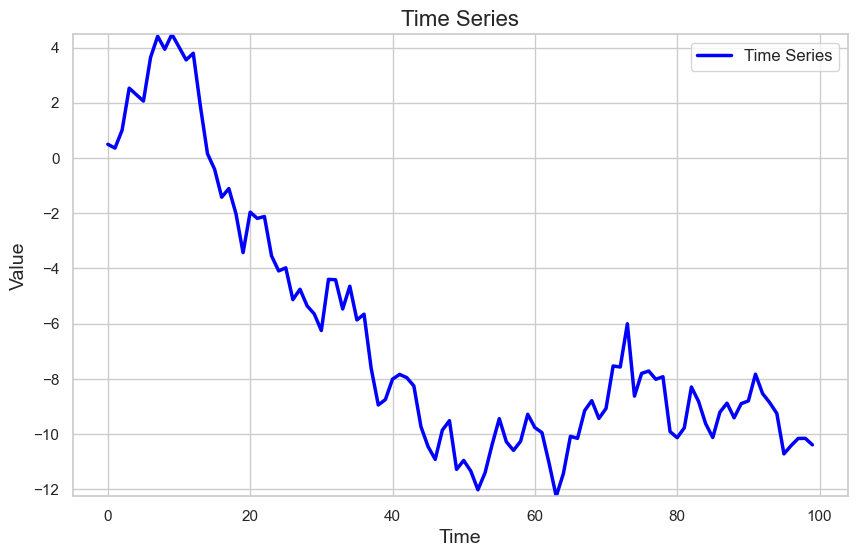

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA


sns.set(style="whitegrid")


def generate_nonstationary_series(n=100):
    np.random.seed(42)
    random_walk = np.cumsum(np.random.normal(0, 1, n))
    return pd.Series(random_walk)

ts_data = generate_nonstationary_series()


plt.figure(figsize=(10, 6))
plt.plot(ts_data, label='Time Series', linewidth=2.5, color='blue')
plt.title("Time Series", fontsize=16)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.ylim(bottom=min(ts_data), top=max(ts_data))
plt.legend(fontsize=12)
plt.show()

In [51]:

def adf_test(series):
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    if result[1] <= 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary, differencing is required.")

print("ADF Test for Original Series:")
adf_test(ts_data)

ADF Test for Original Series:
ADF Statistic: -1.3583317659818994
p-value: 0.6020814791099097
The series is not stationary, differencing is required.


In [52]:

ts_diff = ts_data.diff().dropna()


print("\nADF Test for Differenced Series:")
adf_test(ts_diff)


ADF Test for Differenced Series:
ADF Statistic: -10.008881137130235
p-value: 1.8006877207195796e-17
The series is stationary.


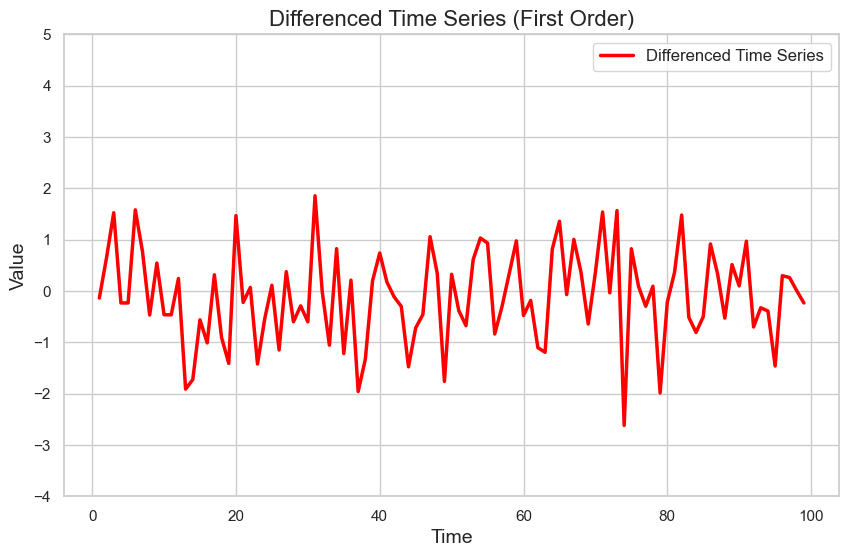

In [53]:

plt.figure(figsize=(10, 6))
plt.plot(ts_diff, label='Differenced Time Series', linewidth=2.5, color='red')
plt.title("Differenced Time Series (First Order)", fontsize=16)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.ylim(bottom=-4, top=5)
plt.legend(fontsize=12)
plt.show()

In [54]:

model = ARIMA(ts_data, order=(1, 1, 1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -131.425
Date:                Wed, 06 May 2026   AIC                            268.850
Time:                        20:50:21   BIC                            276.635
Sample:                             0   HQIC                           272.000
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3997      5.647      0.071      0.944     -10.667      11.467
ma.L1         -0.4158      5.589     -0.074      0.941     -11.370      10.538
sigma2         0.8329      0.123      6.780      0.0

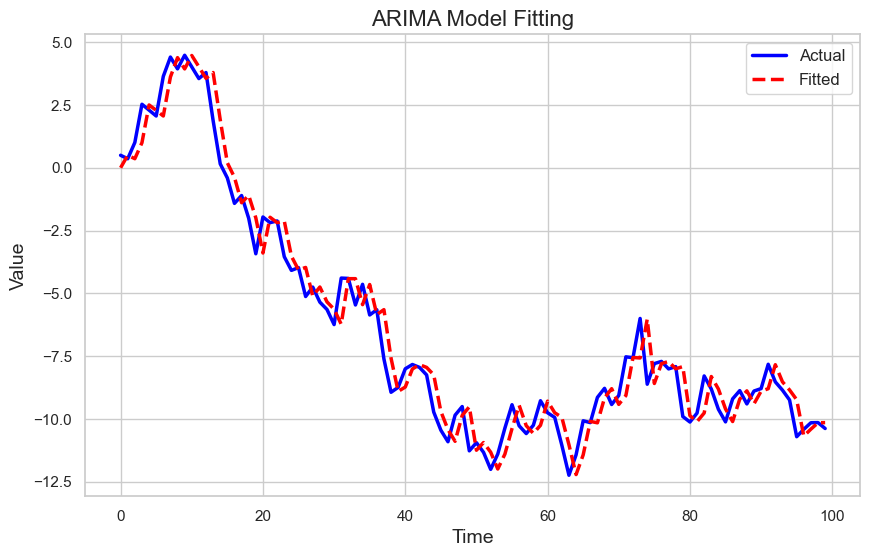

In [55]:

plt.figure(figsize=(10, 6))
plt.plot(ts_data, label="Actual", linewidth=2.5, color='blue')
plt.plot(model_fit.fittedvalues, label="Fitted", linestyle="--", linewidth=2.5, color='red')
plt.legend(fontsize=12)
plt.title("ARIMA Model Fitting", fontsize=16)
plt.xlabel("Time", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.show()

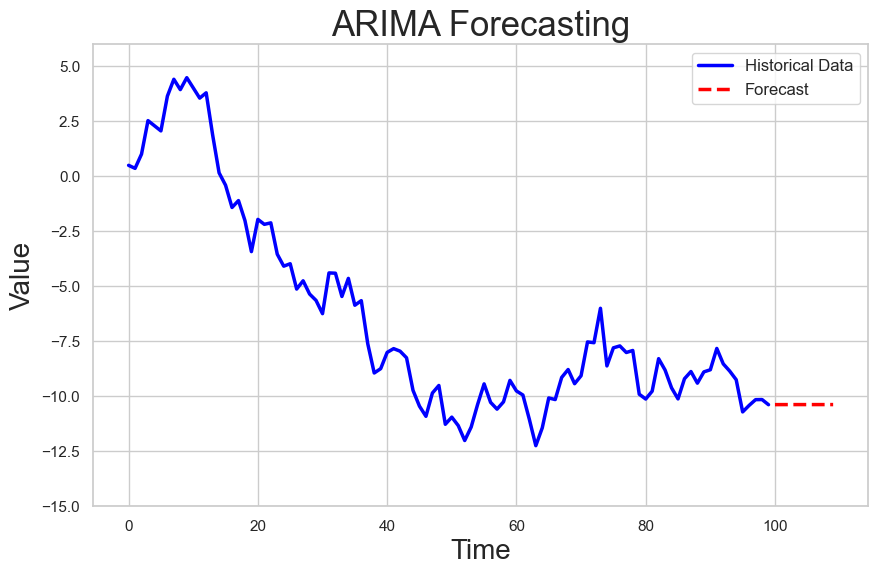

In [56]:

forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)
plt.figure(figsize=(10, 6))
plt.plot(ts_data, label="Historical Data", linewidth=2.5, color='blue')
plt.plot(range(len(ts_data), len(ts_data) + forecast_steps), forecast, label="Forecast", linestyle="--", linewidth=2.5, color='red')
plt.legend(fontsize=12)
plt.title("ARIMA Forecasting", fontsize=25)
plt.xlabel("Time", fontsize=20)
plt.ylabel("Value", fontsize=20)
plt.ylim(top = 6, bottom= -15)
plt.show()


---

# Full workflow example: Airline passengers

Steps: **(1)** load series → *(optional)* **Cell 1 method**: OLS \(\hat{c},\hat{\phi}\) on pre‑1958 train, same **`forecast`** array + recurrence as Cell 1 → **(2)** ADF stationarity test → **(3)** choose integration order \(d\) → **(4)** identify \(p,q\) with ACF/PACF → **(5)** fit ARIMA → **(6)** forecast.

Data: **AirPassengers** via `statsmodels.datasets.get_rdataset` (monthly passengers). **Steps 5–6** use **`statsmodels.tsa.arima.model.ARIMA`** with **`seasonal_order`** (period 12).

**Optional — sktime:** If you want `from sktime.forecasting.arima import StatsModelsARIMA`, install **`pip install scikit-base`** (provides the `skbase` module sktime imports) in the **same Python environment as your Jupyter kernel**.


## Step 1 — Load a time series


In [57]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore", category=FutureWarning)

# Match MA.ipynb: same default figure size as plain plt.figure()
FIGSIZE = tuple(map(float, plt.rcParams["figure.figsize"]))

# AirPassengers from Rdatasets (no sktime/skbase required for data loading)
_air = sm.datasets.get_rdataset("AirPassengers", "datasets").data
# Rdatasets "time" is decimal year (float); do NOT pass it to pd.date_range — pandas
# interprets numeric starts as offsets from Unix epoch → wrong calendar (≈1970s).
# Match MA.ipynb / textbook: monthly index 1949-01 … 1960-12.
_idx = pd.date_range("1949-01-01", periods=len(_air), freq="MS")
y = pd.Series(_air["value"].astype(float).values, index=_idx)

# Statsmodels uses index freq for forecast calendar; ensure inferrable frequency
_freq = pd.infer_freq(y.index)
if _freq is not None:
    y = y.copy()
    y.index = pd.DatetimeIndex(y.index, freq=_freq)

plt.figure(figsize=FIGSIZE)
plt.plot(y, label="Original Time Series", linewidth=2)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

## Step 2 — Stationarity test (ADF)

**Augmented Dickey–Fuller**: the null hypothesis is a unit root (non-stationarity). If **p-value > 0.05**, we fail to reject \(H_0\) → differencing is usually needed.


In [ ]:
def adf_row(name, series):
    s = series.dropna()
    stat, p, *_rest = adfuller(s, autolag="AIC")
    return {"series": name, "ADF statistic": stat, "p-value": p}


adf_orig = pd.DataFrame([adf_row("levels", y)])
display(adf_orig)
p0 = adf_orig["p-value"].iloc[0]
print(
    "Fail to reject H0 → series is typically NOT stationary; differencing needed"
    if p0 > 0.05
    else "Reject H0 → stationary at 5%"
)


,series,ADF statistic,p-value
0,levels,0.815369,0.99188


Fail to reject H0 → series is typically NOT stationary; differencing needed


## Step 3 — Pick \(d\) to obtain stationarity

Start with the **first difference** \(\Delta y_t = y_t - y_{t-1}\) and run ADF. If **p-value > 0.05** (fail to reject the unit root), test the **second difference** \(\Delta^2 y_t = \Delta(\Delta y_t)\).

**Rule used in this notebook**: if the first difference looks stationary, set **d = 1**; else if the second difference looks stationary, set **d = 2**. If neither rejects the unit root at 5%, monthly series often need **seasonal differencing** \(\Delta_{12}\) or **ARIMA with `seasonal_order`** (see closing note); we still assign a default **d** so the workflow can continue.


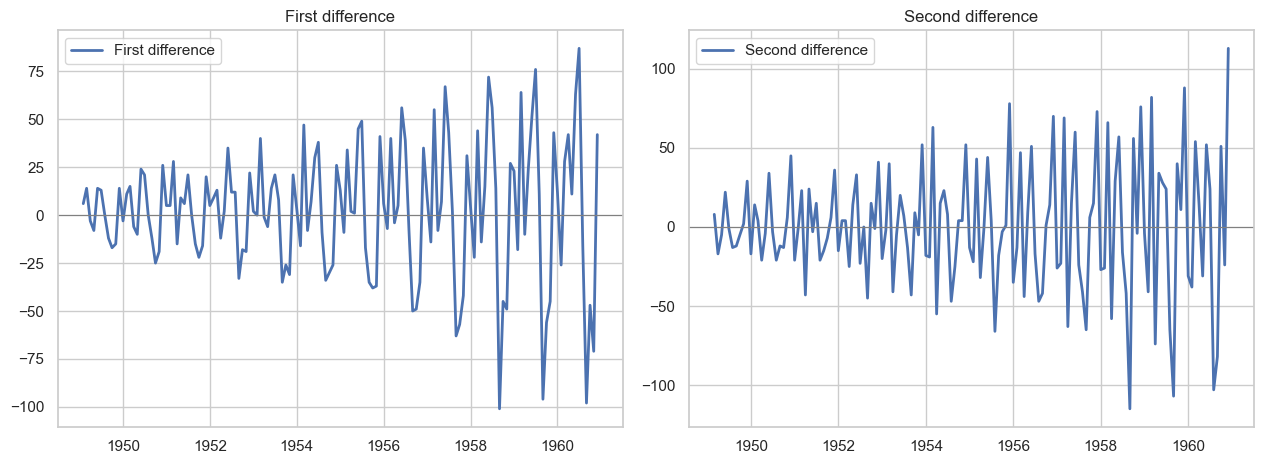

,series,ADF statistic,p-value
0,first difference,-2.829267,5.421329e-02
1,second difference,-16.384232,2.732892e-29


ADF on first difference: fail to reject H0 (p>0.05); second difference rejects H0 → use d = 2.


In [ ]:
dy = y.diff().dropna()
d2y = dy.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2, FIGSIZE[1]))
axes[0].plot(dy, label="First difference", linewidth=2)
axes[0].axhline(0.0, color="gray", lw=0.8)
axes[0].legend()
axes[0].grid(True)
axes[0].set_title("First difference")

axes[1].plot(d2y, label="Second difference", linewidth=2)
axes[1].axhline(0.0, color="gray", lw=0.8)
axes[1].legend()
axes[1].grid(True)
axes[1].set_title("Second difference")

plt.tight_layout()
plt.show()

adf_diff = pd.DataFrame(
    [
        adf_row("first difference", dy),
        adf_row("second difference", d2y),
    ]
)
display(adf_diff)

p1 = adf_diff.loc[adf_diff["series"] == "first difference", "p-value"].iloc[0]
p2 = adf_diff.loc[adf_diff["series"] == "second difference", "p-value"].iloc[0]

if p1 <= 0.05:
    d = 1
    print("ADF on first difference: reject H0 (p≤0.05) → use d = 1.")
elif p2 <= 0.05:
    d = 2
    print(
        "ADF on first difference: fail to reject H0 (p>0.05); "
        "second difference rejects H0 → use d = 2."
    )
else:
    d = 1
    print(
        "ADF: both first and second differences still have p>0.05 at 5%. "
        "For monthly airline traffic, seasonal differencing / ARIMA with seasonal_order is often needed; "
        "this notebook keeps d = 1 to continue the workflow — interpret with caution."
    )

# Identification series for Step 4 (matches ARMA on Δ^d y)
z = dy if d == 1 else d2y


### Step 3b — Additional stationarity tests (KPSS, RUR)

Besides **ADF**, two common cross-checks (still using a 5% significance level):

| Test | Null \(H_0\) | If **p ≤ 0.05** |
|------|----------------|----------------|
| **ADF** | Unit root (overall non-stationarity) | Reject \(H_0\) → evidence of **stationarity** |
| **KPSS** (`regression='c'`) | **Level stationarity** | Reject \(H_0\) → evidence of **non-stationarity** |
| **RUR** | **Stationarity** | Reject \(H_0\) → evidence of **non-stationarity** |

**ADF and KPSS sometimes disagree** (e.g. with strong trends)—do not rely on p-values alone; use plots, differenced ACFs, and consider **seasonal differencing / seasonal ARIMA**.

The table below reports p-values for **levels**, **first difference**, and **second difference**.


In [ ]:
from statsmodels.tsa.stattools import kpss, range_unit_root_test


def multi_test_row(name, series):
    s = series.dropna().astype(float)
    _, adf_p, *_ = adfuller(s, autolag="AIC")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        _, kpss_p, *_ = kpss(s, regression="c", nlags="auto")
    _, rur_p, *_ = range_unit_root_test(s)
    return {
        "series": name,
        "ADF p   [H0: unit root]": adf_p,
        "KPSS p [H0: level stationary]": kpss_p,
        "RUR p        [H0: stationary]": rur_p,
    }


summary = pd.DataFrame(
    [
        multi_test_row("levels", y),
        multi_test_row("first difference", dy),
        multi_test_row("second difference", d2y),
    ]
)
display(summary)


,series,ADF p [H0: unit root],KPSS p [H0: level stationary],RUR p [H0: stationary]
0,levels,9.918802e-01,0.01,0.9
1,first difference,5.421329e-02,0.10,0.9
2,second difference,2.732892e-29,0.10,0.9


## Step 4 — Identification of \(p\) and \(q\)

- **ACF**: often used for **MA order \(q\)** (error lags).
- **PACF**: partial autocorrelation after intermediate lags; often used for **AR order \(p\)**.

Below: ACF/PACF for **`z`**, the **\(d\)**-times differenced series (**first or second difference**, chosen in Step 3).


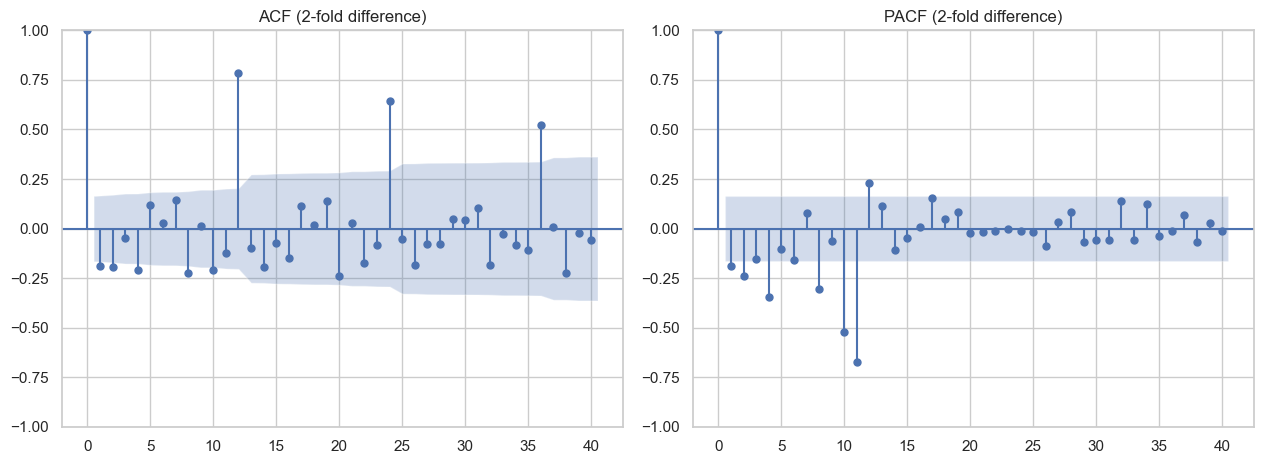

In [ ]:
lags = 40
_id_label = f"{d}-fold difference" if d > 1 else "first difference"
fig, axes = plt.subplots(1, 2, figsize=(FIGSIZE[0] * 2, FIGSIZE[1]))
plot_acf(z, ax=axes[0], lags=lags, title=f"ACF ({_id_label})")
plot_pacf(z, ax=axes[1], lags=lags, method="ywm", title=f"PACF ({_id_label})")
axes[0].grid(True)
axes[1].grid(True)
plt.tight_layout()
plt.show()


## Step 5 — Fit ARIMA model

Monthly series often show a **12-month** seasonal cycle. Here we use **`statsmodels.tsa.arima.model.ARIMA`** with **`order`** and **`seasonal_order`** (same model class that sktime's `StatsModelsARIMA` wraps once `scikit-base` is installed).

Example: **`order=(0, 1, 1)`** and **`seasonal_order=(1, 1, 1, 12)`** (refine using Step 4 ACF/PACF or AIC/BIC).

**Train / test split:** fit the model only on months **before 1958-01** (`y_train`); reserve **Jan 1958–Dec 1960** (`y_test`) for out-of-sample forecasts in Step 6. Below, the dashed line is **in-sample fitted values on the training window** only; the full observed series is shown for context.


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  108
Model:                 ARIMA(8, 2, 8)   Log Likelihood                -430.491
Date:                Wed, 06 May 2026   AIC                            894.983
Time:                        20:00:27   BIC                            940.261
Sample:                    01-01-1949   HQIC                           913.335
                         - 12-01-1957                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1853      0.111     -1.675      0.094      -0.402       0.031
ar.L2         -0.0272      0.109     -0.248      0.804      -0.242       0.187
ar.L3          0.2245      0.103      2.178      0.0

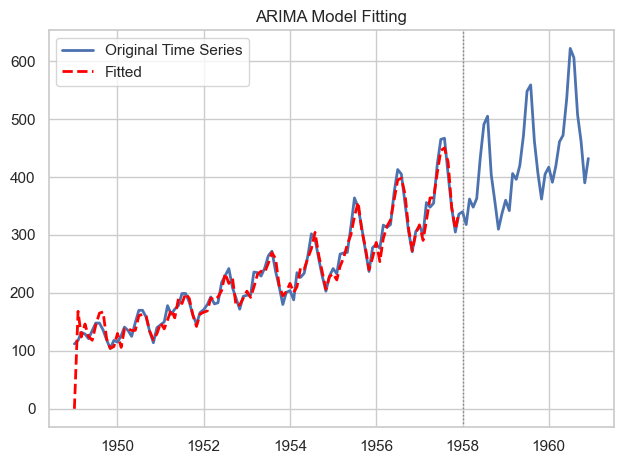

In [ ]:
# Non-seasonal (p,d,q) and seasonal (P,D,Q); seasonal period s=12 months
ORDER = (8, 2, 8)

SEASONAL_ORDER = (1, 1, 1, 12)

# Fit only on data before Jan 1958; hold out Jan 1958–Dec 1960 for Step 6
SPLIT = pd.Timestamp("1958-01-01")
y_train = y.loc[y.index < SPLIT].copy()
y_test = y.loc[y.index >= SPLIT].copy()

model = ARIMA(y_train, order=ORDER)
res = model.fit()
print(res.summary())

fitted = res.fittedvalues

plt.figure(figsize=FIGSIZE)
plt.plot(y, label="Original Time Series", linewidth=2, color="C0")
plt.plot(fitted, label="Fitted", linestyle="--", linewidth=2, color="red")
plt.axvline(SPLIT, color="gray", linestyle=":", linewidth=1)
plt.title("ARIMA Model Fitting")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Step 6 — Forecast from 1958 onward

Using the model from Step 5 (trained **only** on pre-1958 data), forecast **`len(y_test)`** steps ahead and plot next to the full observed series — the **ARIMA** line covers **1958–1960** only (out-of-sample), comparable in spirit to `MA.ipynb`’s tail overlay.


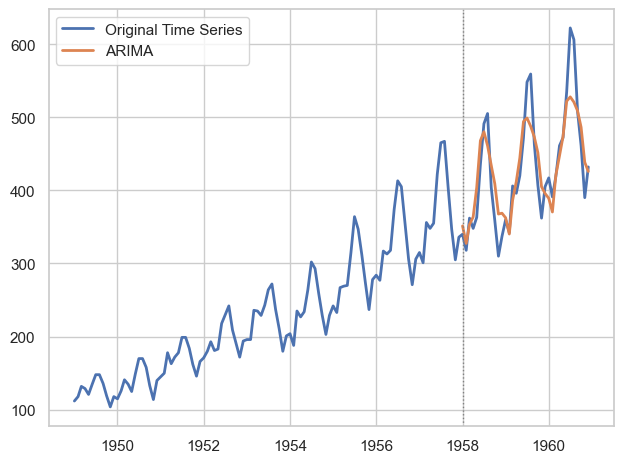

In [ ]:
h = len(y_test)
fc_raw = res.forecast(steps=h)
vals = fc_raw.values if hasattr(fc_raw, "values") else np.asarray(fc_raw)
fc = pd.Series(vals, index=y_test.index)

plt.figure(figsize=FIGSIZE)
plt.plot(y, label="Original Time Series", linewidth=2, color="C0")
plt.plot(fc, label="ARIMA", linewidth=2, color="C1")
plt.axvline(SPLIT, color="gray", linestyle=":", linewidth=1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  108
Model:             ARIMA(8, 2, 8)x(1, 1, [1], 12)   Log Likelihood                -342.224
Date:                            Wed, 06 May 2026   AIC                            722.449
Time:                                    20:09:12   BIC                            770.771
Sample:                                01-01-1949   HQIC                           741.968
                                     - 12-01-1957                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3382      9.260     -0.145      0.885     -19.488      16.811
ar.L2         -1.9870      3.053   

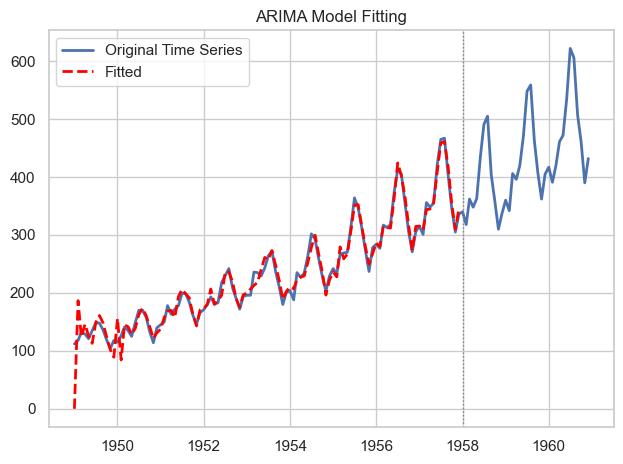

In [ ]:
# Non-seasonal (p,d,q) and seasonal (P,D,Q); seasonal period s=12 months
ORDER = (8, 2, 8)

SEASONAL_ORDER = (1, 1, 1, 12)

# Fit only on data before Jan 1958; hold out Jan 1958–Dec 1960 for Step 6
SPLIT = pd.Timestamp("1958-01-01")
y_train = y.loc[y.index < SPLIT].copy()
y_test = y.loc[y.index >= SPLIT].copy()

model = ARIMA(y_train, order=ORDER, seasonal_order=SEASONAL_ORDER)
res = model.fit()
print(res.summary())

fitted = res.fittedvalues

plt.figure(figsize=FIGSIZE)
plt.plot(y, label="Original Time Series", linewidth=2, color="C0")
plt.plot(fitted, label="Fitted", linestyle="--", linewidth=2, color="red")
plt.axvline(SPLIT, color="gray", linestyle=":", linewidth=1)
plt.title("ARIMA Model Fitting")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


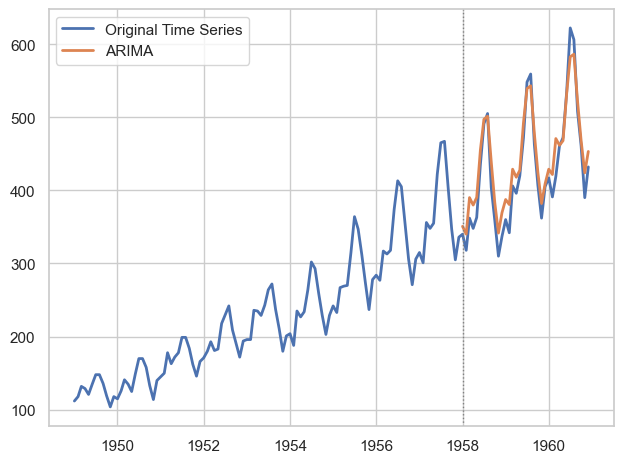

In [ ]:
h = len(y_test)
fc_raw = res.forecast(steps=h)
vals = fc_raw.values if hasattr(fc_raw, "values") else np.asarray(fc_raw)
fc = pd.Series(vals, index=y_test.index)

plt.figure(figsize=FIGSIZE)
plt.plot(y, label="Original Time Series", linewidth=2, color="C0")
plt.plot(fc, label="ARIMA", linewidth=2, color="C1")
plt.axvline(SPLIT, color="gray", linestyle=":", linewidth=1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Note (monthly seasonal data)

In practice you can also use train/validation splits, compare orders with **AIC/BIC**, and run residual diagnostics such as **Ljung–Box**.
